In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import matplotlib.ticker as ticker
import matplotlib.patches as mpl_patches

In [2]:
df=pd.read_table('FigS6b.txt')
df.head()

,accession,phenotype_value,genotype
0,108,91.0,0
1,139,26.0,0
2,159,81.0,0
3,265,32.0,0
4,350,65.0,0


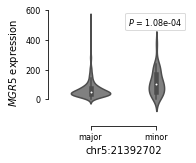

In [8]:
boxprops = {'edgecolor': 'black', 'linewidth': 0.5, 'facecolor': 'grey'}
lineprops = {'color': 'k', 'linewidth': 0.5}
boxplot_kwargs = dict({'boxprops': boxprops, 'medianprops': lineprops,
                       'whiskerprops': lineprops, 'capprops': lineprops,
                       'width': 0.6})

alt=df[df['genotype'] == '1']
ref=df[df['genotype'] == '0']

Order=['0','1']

@ticker.FuncFormatter
def major_formatter(x, pos):
    y = x /1000000
    return "%.0f" % y
cm = 1/2.54
plt.figure(figsize=(6*cm,5*cm))
ax=sns.violinplot(x='genotype', 
            y='phenotype_value',
            color='grey',
            data=df,
            order=Order,
            linewidth=1.5,
            fliersize=0,
            **boxplot_kwargs)
r,p = mannwhitneyu(alt['phenotype_value'],ref['phenotype_value'])
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 2
labels=[]
labels.append(r"$P$ = {:.2e}".format(p))
plt.legend(handles, labels, loc='best', fontsize=8, 
      fancybox=True, framealpha=0.7, 
      handlelength=0, handletextpad=0)
ax.set_xlabel('chr5:21392702',fontsize=10)
ax.set_xticklabels(['major', 'minor'])
plt.ylabel('$\itMGR5$ expression',fontsize=10)

sns.despine(trim=True,offset=10)
plt.tick_params(labelsize=8)
# plt.savefig("FigS6b.pdf", format="pdf",bbox_inches="tight",facecolor='w')